# NDVI Time Series for Agricultural Monitoring

This tutorial demonstrates how to compute and visualize NDVI (Normalized Difference Vegetation Index) time series using the FAO OpenEO backend. NDVI is a widely used indicator for monitoring vegetation health and agricultural productivity.

**What you will learn:**
- How to load multi-temporal satellite data
- How to apply band math to compute vegetation indices
- How to aggregate time series over regions of interest
- How to visualize temporal vegetation dynamics
- How to compare vegetation conditions across multiple zones

**Prerequisites:**
- Completed the [Getting Started](01_getting_started.ipynb) tutorial
- `openeo`, `matplotlib`, `pandas`, `numpy` packages installed

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/un-fao/openeo-docs/blob/main/tutorials/02_ndvi_time_series.ipynb)

In [ ]:
# !pip install openeo matplotlib pandas numpy rasterio

## 1. Connect and Authenticate

In [1]:
import openeo
import json

# Connect to the FAO OpenEO backend
connection = openeo.connect("https://data.fao.org/openeo")

print(f"Connected to: {connection.root_url}")
print(f"API version: {connection.capabilities().api_version()}")

Connected to: https://data.fao.org/openeo/
API version: 1.2.0


In [2]:
# Authenticate via OIDC — this will open a browser window for FAO SSO login
connection.authenticate_oidc(provider_id="keycloak")

# Verify authentication
user_info = connection.describe_account()
print(f"Logged in as: {user_info}")

Authenticated using refresh token.
Logged in as: {'user_id': '2aec56d2-02dc-4538-be21-402932593fce', 'name': 'Abdallah Hadid', 'default_plan': None, 'storage': {'free': 107374155251, 'quota': 107374182400}, 'budget': None, 'links': []}


## 2. Understand VCI — A Proxy for Vegetation Health

The FAO backend provides pre-computed vegetation indices like **VCI-D** (Vegetation Condition Index — Dekadal). VCI normalizes NDVI relative to its historical min and max, indicating how current vegetation compares to the long-term range:

- **VCI < 0.35**: Drought / stressed vegetation
- **VCI 0.35–0.5**: Below normal
- **VCI 0.5–0.7**: Normal
- **VCI > 0.7**: Above normal / good conditions

Let's build a time series of VCI over agricultural fields in the Nile Delta.

## 3. Define Area of Interest

We define two agricultural zones in the Nile Delta to compare vegetation conditions.

In [3]:
# Two zones in the Nile Delta for comparison
zones = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "Northern Zone"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [31.22, 30.05], [31.22, 30.08],
                    [31.30, 30.08], [31.30, 30.05],
                    [31.22, 30.05]
                ]]
            }
        },
        {
            "type": "Feature",
            "properties": {"name": "Southern Zone"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [31.22, 30.01], [31.22, 30.04],
                    [31.30, 30.04], [31.30, 30.01],
                    [31.22, 30.01]
                ]]
            }
        },
    ]
}

print(f"Defined {len(zones['features'])} zones for analysis.")
for f in zones["features"]:
    print(f"  - {f['properties']['name']}")

Defined 2 zones for analysis.
  - Northern Zone
  - Southern Zone


## 4. Load VCI Data

We load a full year of dekadal VCI data.

In [ ]:
# Load VCI for the full year 2020
cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent={
        "west": 31.2,
        "east": 31.35,
        "south": 30.0,
        "north": 30.1,
    },
    temporal_extent=["2020-01-01", "2020-12-31"],
)

print("Data cube loaded.")

Data cube loaded.


## 5. Aggregate VCI Over Zones

We use `aggregate_spatial` to compute the mean VCI within each zone at every timestep. This produces a time series per zone.

In [5]:
# Aggregate spatially: compute mean VCI per zone per timestep
zonal_ts = cube.aggregate_spatial(
    geometries=zones,
    reducer="mean",
)

# Execute and download as JSON
result = json.loads(zonal_ts.save_result(format="JSON").download())
print(f"Result type: {type(result)}")
print(f"Result preview: {json.dumps(result, indent=2)[:800]}...")

Result type: <class 'list'>
Result preview: [
  {
    "time": "2020-01-01T00:00:00Z",
    "geometry": "geometry_0",
    "spatial_ref": 0,
    "variable": "data",
    "value": 0.2957499996,
    "item_id": "ASIS.VCI-D.2020-01-D1",
    "start_datetime": "2020-01-01T00:00:00Z",
    "end_datetime": "2020-01-10T00:00:00Z",
    "name": "Northern Zone"
  },
  {
    "time": "2020-01-01T00:00:00Z",
    "geometry": "geometry_1",
    "spatial_ref": 0,
    "variable": "data",
    "value": 0.3236249989,
    "item_id": "ASIS.VCI-D.2020-01-D1",
    "start_datetime": "2020-01-01T00:00:00Z",
    "end_datetime": "2020-01-10T00:00:00Z",
    "name": "Southern Zone"
  },
  {
    "time": "2020-01-11T00:00:00Z",
    "geometry": "geometry_0",
    "spatial_ref": 0,
    "variable": "data",
    "value": 0.4008750029,
    "item_id": "ASIS.VCI-D.2020-01-D2",
   ...


## 6. Visualize the Time Series

Let's plot the VCI time series for both zones to compare vegetation health throughout the year.

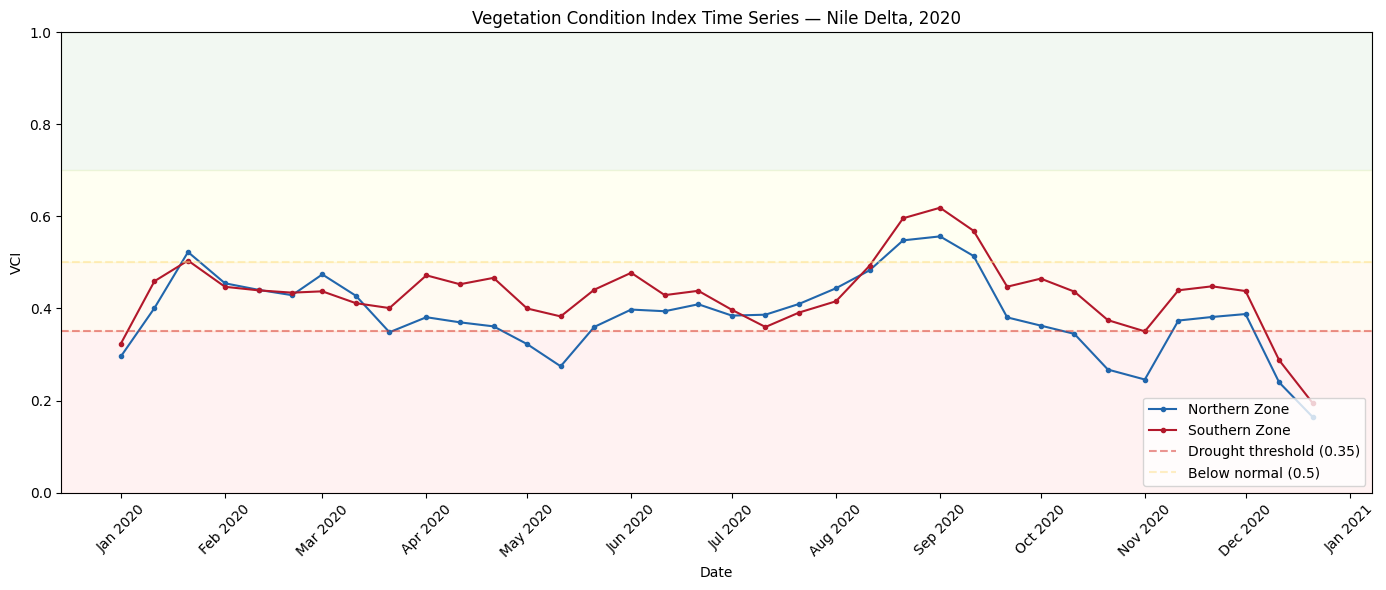

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Parse the list-of-dicts result into a DataFrame
df = pd.DataFrame(result)
df["time"] = pd.to_datetime(df["time"])

fig, ax = plt.subplots(figsize=(14, 6))

colors = ["#2166ac", "#b2182b"]

for idx, (zone_name, group) in enumerate(df.groupby("name")):
    group = group.sort_values("time")
    ax.plot(group["time"], group["value"], marker="o", markersize=3, linewidth=1.5,
            color=colors[idx % len(colors)], label=zone_name)

# Add drought threshold reference lines
ax.axhline(y=0.35, color="#d73027", linestyle="--", alpha=0.5, label="Drought threshold (0.35)")
ax.axhline(y=0.5, color="#fee08b", linestyle="--", alpha=0.5, label="Below normal (0.5)")

# Add background shading for vegetation condition categories
ax.axhspan(0, 0.35, alpha=0.05, color="red")
ax.axhspan(0.35, 0.5, alpha=0.05, color="orange")
ax.axhspan(0.5, 0.7, alpha=0.05, color="yellow")
ax.axhspan(0.7, 1.0, alpha=0.05, color="green")

ax.set_xlabel("Date")
ax.set_ylabel("VCI")
ax.set_title("Vegetation Condition Index Time Series — Nile Delta, 2020")
ax.legend(loc="lower right")
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Compute Monthly Aggregates

For a smoother view, we can aggregate the dekadal data into monthly means using `aggregate_temporal_period`.

In [7]:
# Aggregate to monthly means
monthly_cube = cube.aggregate_temporal_period(
    period="month",
    reducer="mean",
)

# Compute temporal mean per month across the whole spatial extent
# and download as GeoTIFF with timestamps flattened into bands
monthly_cube.download(
    "vci_monthly_nile_delta_2020.tif",
    format="GTiff",
    options={"flatten_timestamps": True},
)

print("Monthly VCI downloaded.")

Monthly VCI downloaded.


/tmp/ipykernel_70693/389408717.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


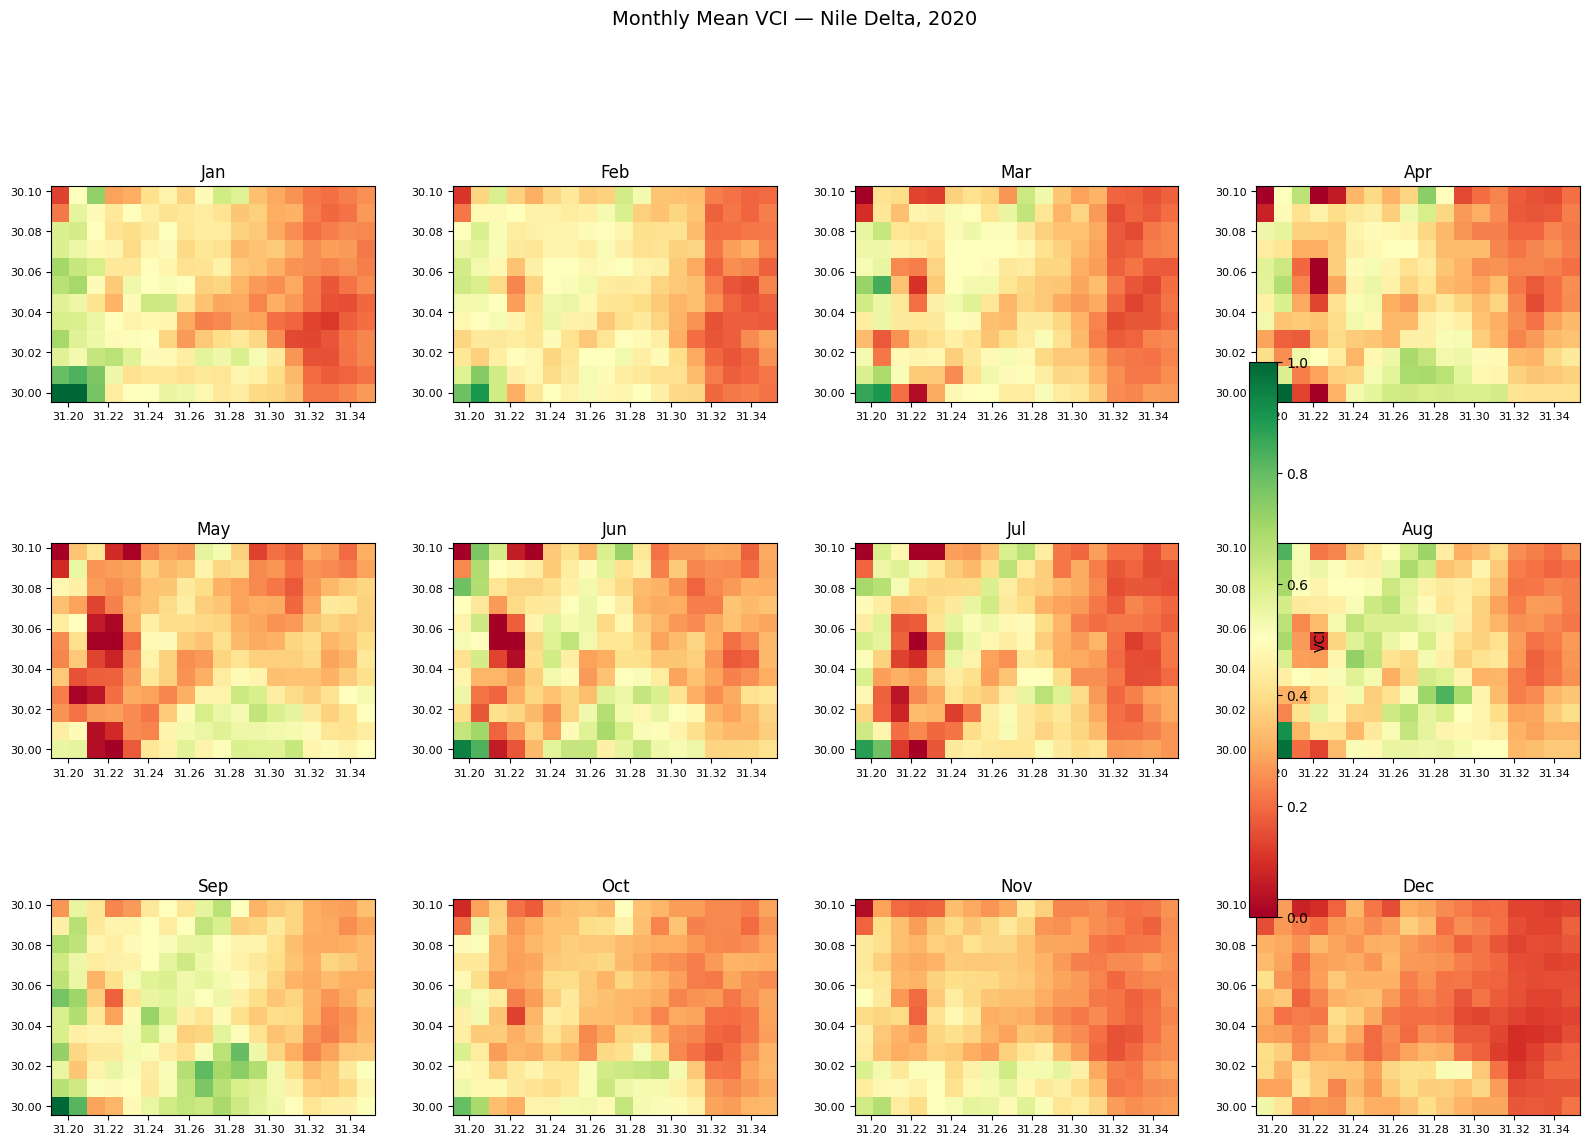

In [8]:
import rasterio

# Visualize monthly VCI maps
with rasterio.open("vci_monthly_nile_delta_2020.tif") as src:
    n_bands = src.count
    bounds = src.bounds

    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    cols = 4
    rows = (min(n_bands, 12) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    for i in range(min(n_bands, 12)):
        data = src.read(i + 1)
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)

        im = axes[i].imshow(
            data,
            extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
            cmap="RdYlGn",
            vmin=0, vmax=1,
        )
        axes[i].set_title(months[i] if i < len(months) else f"Band {i+1}")
        axes[i].tick_params(labelsize=8)

    # Hide unused axes
    for j in range(min(n_bands, 12), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Monthly Mean VCI — Nile Delta, 2020", fontsize=14, y=1.02)
    fig.colorbar(im, ax=axes, label="VCI", shrink=0.6, pad=0.02)
    plt.tight_layout()
    plt.show()

## 8. Detect Vegetation Anomalies

Let's compute a simple vegetation anomaly by comparing the last observation to the temporal mean. Negative anomalies indicate below-average vegetation.

In [9]:
# Compute temporal mean
mean_vci = cube.reduce_dimension(dimension="time", reducer="mean")

# Get the last observation
last_vci = cube.reduce_dimension(dimension="time", reducer="last")

# Compute anomaly: last - mean
anomaly = last_vci - mean_vci

# Download
anomaly.download("vci_anomaly_nile_delta.tif", format="GTiff")
print("Anomaly map downloaded.")

Anomaly map downloaded.


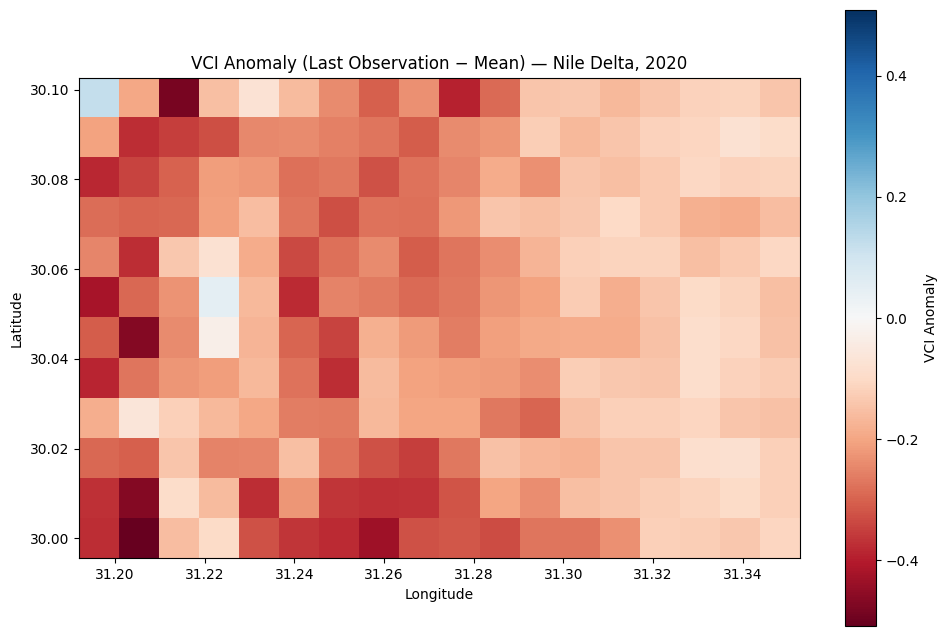

In [10]:
# Visualize the anomaly
with rasterio.open("vci_anomaly_nile_delta.tif") as src:
    data = src.read(1)
    bounds = src.bounds
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)

fig, ax = plt.subplots(figsize=(10, 8))
vmax = max(abs(np.nanmin(data)), abs(np.nanmax(data)))
img = ax.imshow(
    data,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap="RdBu",
    vmin=-vmax, vmax=vmax,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("VCI Anomaly (Last Observation − Mean) — Nile Delta, 2020")
plt.colorbar(img, ax=ax, label="VCI Anomaly", shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Drought Classification Map

We can classify the mean VCI into drought categories using threshold-based logic.

In [ ]:
# Reload and compute mean
cube = connection.load_collection(
    collection_id="fao-gismgr:ASIS:raster:mapsets:VCI-D",
    spatial_extent={"west": 31.2, "east": 31.35, "south": 30.0, "north": 30.1},
    temporal_extent=["2020-01-01", "2020-06-01"],
)

mean_cube = cube.reduce_dimension(dimension="time", reducer="mean")

# Apply threshold: identify drought areas (VCI < 0.35)
drought_mask = mean_cube.apply(lambda x: x < 0.35)

drought_mask.download("drought_mask_nile_delta.tif", format="GTiff")
print("Drought mask downloaded.")

Drought mask downloaded.


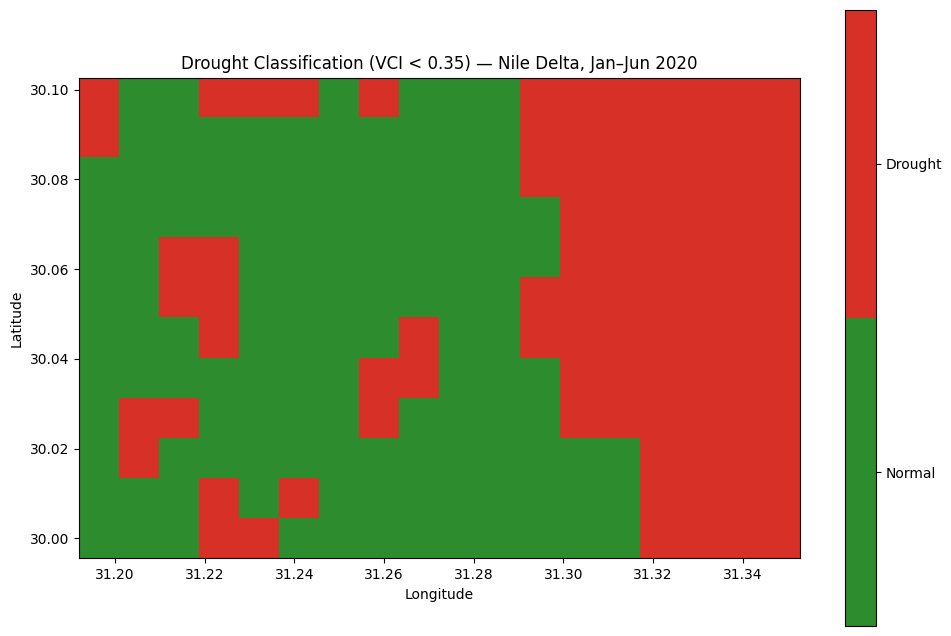

In [12]:
from matplotlib.colors import ListedColormap

with rasterio.open("drought_mask_nile_delta.tif") as src:
    data = src.read(1)
    bounds = src.bounds

fig, ax = plt.subplots(figsize=(10, 8))
cmap = ListedColormap(["#2d8c2d", "#d73027"])
img = ax.imshow(
    data,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    cmap=cmap,
    vmin=0, vmax=1,
    interpolation="nearest",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Drought Classification (VCI < 0.35) — Nile Delta, Jan–Jun 2020")
cbar = plt.colorbar(img, ax=ax, ticks=[0.25, 0.75], shrink=0.8)
cbar.ax.set_yticklabels(["Normal", "Drought"])
plt.tight_layout()
plt.show()

## Summary

In this tutorial, you learned how to:

1. **Load multi-temporal vegetation data** from the FAO VCI collection
2. **Aggregate time series** over zones of interest using `aggregate_spatial`
3. **Aggregate temporally** into monthly means with `aggregate_temporal_period`
4. **Compute vegetation anomalies** by comparing observations to the mean
5. **Create drought classification maps** using threshold logic
6. **Visualize** results as time series charts and spatial maps

### Next Steps

- **[Zonal Statistics](03_zonal_statistics.ipynb)** — Compute detailed statistics over administrative boundaries
- **[Climate Risk Assessment](04_climate_risk_crtb.ipynb)** — Assess climate hazards and vulnerabilities
- Try different collections like **ASI-D** (Agricultural Stress Index) or **L1-AETI-M** (Actual Evapotranspiration)